# Some figures that we are not using so far

Dual occluders
- All averaged trajectories per mouse ✅
- Initial start per mouse and averaged ✅
- Tortuosity and duration ✅
- p values in trial progression plots for each line (in Fig 2-3)
- distance to choice ✅
- heading direction ✅
- head-body angle ✅
- vel x and y ✅
- prediction with only one params vs all the params in the logistic regression ?

Multiple occluders: all that was not shown
- All averaged trajectories ✅
- trial left choice proba ✅


Per lab data
- trial count

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-02-13 17:24:04,651::INFO::settings.py::Setting loglevel to INFO
2025-02-13 17:24:04,653::INFO::settings.py::Setting stores to {}
2025-02-13 17:24:04,654::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-13 17:24:04,654::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-13 17:24:04,655::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-13 17:24:04,656::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-02-13 17:24:04,657::INFO::settings.py::Setting database.user to celia
2025-02-13 17:24:04,657::INFO::settings.py::Setting database.password to celia_mathislab


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-02-13 17:24:05,300::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
2025-02-13 17:24:05,406::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:05,817::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:05,817::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:06,257::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:06,257::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:06,404::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:06,404::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:06,740::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:06,740::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:07,210::INFO::table.py::could not log event in table ~log
2025-02-13 17:24:07,210::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

# Training

In [5]:
niell_data = pd.read_pickle("big_df_contrast_training_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_training.pkl")

big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)

In [6]:
def get_training_stage_per_mouse(big_df, mouse_name):
    new_df_list = []
    mouse_df = big_df[big_df.mouse_name == mouse_name].copy()

    df = mouse_df[(mouse_df.training_stage == "ar_detection_no_velthr")].copy()
    early = df[df.session_increment == df.session_increment.unique()[0]].copy()
    early["num_train_stage"] = 0
    new_df_list.append(early)

    mid = df[df.session_increment == df.session_increment.unique()[-1]].copy()  # -2
    mid["num_train_stage"] = 1
    new_df_list.append(mid)

    df = mouse_df[(mouse_df.training_stage == "ar_detection_velthr")].copy()
    late = df[df.session_increment == df.session_increment.unique()[-1]].copy()  # 0
    late["num_train_stage"] = 2
    new_df_list.append(late)

    df = mouse_df[(mouse_df.training_stage == "ar_discrim")].copy()

    early = df[df.session_increment == df.session_increment.unique()[0]].copy()
    early["num_train_stage"] = 3
    new_df_list.append(early)

    late = df[df.session_increment == df.session_increment.unique()[-1]].copy()  # 1
    late["num_train_stage"] = 5
    new_df_list.append(late)

    if len(df.session_increment.unique()) > 2:
        mid = df[df.session_increment == df.session_increment.unique()[-2]].copy()
        mid["num_train_stage"] = 4
        new_df_list.append(mid)
    return pd.concat(new_df_list)


def training_plots(
    big_df,
    mouse_name,
    variable,
    ax,
    ylim=(0.4, 1),
    midpoint_line=True,
    criterion_line=True,
    ylabel="Success rate/session",
    xlabel="Session",
    cmap=["#3FB47C", "#1F6F49", "#FF1493"],
    s=100,
):

    big_df = big_df.copy()
    mean_mouse = big_df.groupby(
        ["mouse_name", "training_stage", "num_train_stage", "trial"], as_index=False
    ).mean(numeric_only=True)
    mean_mouse = mean_mouse.groupby(
        ["mouse_name", "training_stage", "num_train_stage"], as_index=False
    ).mean(numeric_only=True)
    data = mean_mouse[mean_mouse.mouse_name == mouse_name].copy()
    sns.lineplot(
        data=data,
        x="num_train_stage",
        y=variable,
        color="black",
        legend=None,
        alpha=0.5,
        ax=ax,
    )
    sns.scatterplot(
        data=data,
        x="num_train_stage",
        y=variable,
        hue="training_stage",
        palette=cmap,
        alpha=0.9,
        legend=None,
        zorder=100,
        s=s,
        ax=ax,
    )

    if variable == "trial_rewarded":
        ax.set_ylim(ylim[0], ylim[1])
        if midpoint_line:
            ax.axhline(0.5, linestyle="dashed", color="black", alpha=0.5)
        if criterion_line:
            ax.axhline(0.70, linestyle="dashed", color="red", alpha=0.3)
    if variable == "trial_count":
        ax.axhline(125, linestyle="dashed", color="red", alpha=0.3)

    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    sns.despine(offset=10)


def days_in_training_stage(big_df, mouse_name):
    mean_mouse = big_df[big_df.mouse_name == mouse_name]
    mean_mouse = mean_mouse.groupby(["training_stage"], as_index=False)[
        "session"
    ].nunique()
    return mean_mouse

In [7]:
big_df = big_df[big_df.mouse_name != "Vegavis"]
big_df = big_df[big_df.dataset != "Nightingale_2024-07-31_2"]
big_df = big_df[big_df.dataset != "Kiwi_2024-08-08_3"]
big_df["session_increment"] = (
    big_df.groupby("mouse_name")["dataset"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

big_df["trial_count"] = big_df.groupby("dataset")["trial"].transform("nunique")
big_df["session_duration"] = (
    big_df.groupby("dataset").trial.transform("count") * 0.02 / 3600
).values

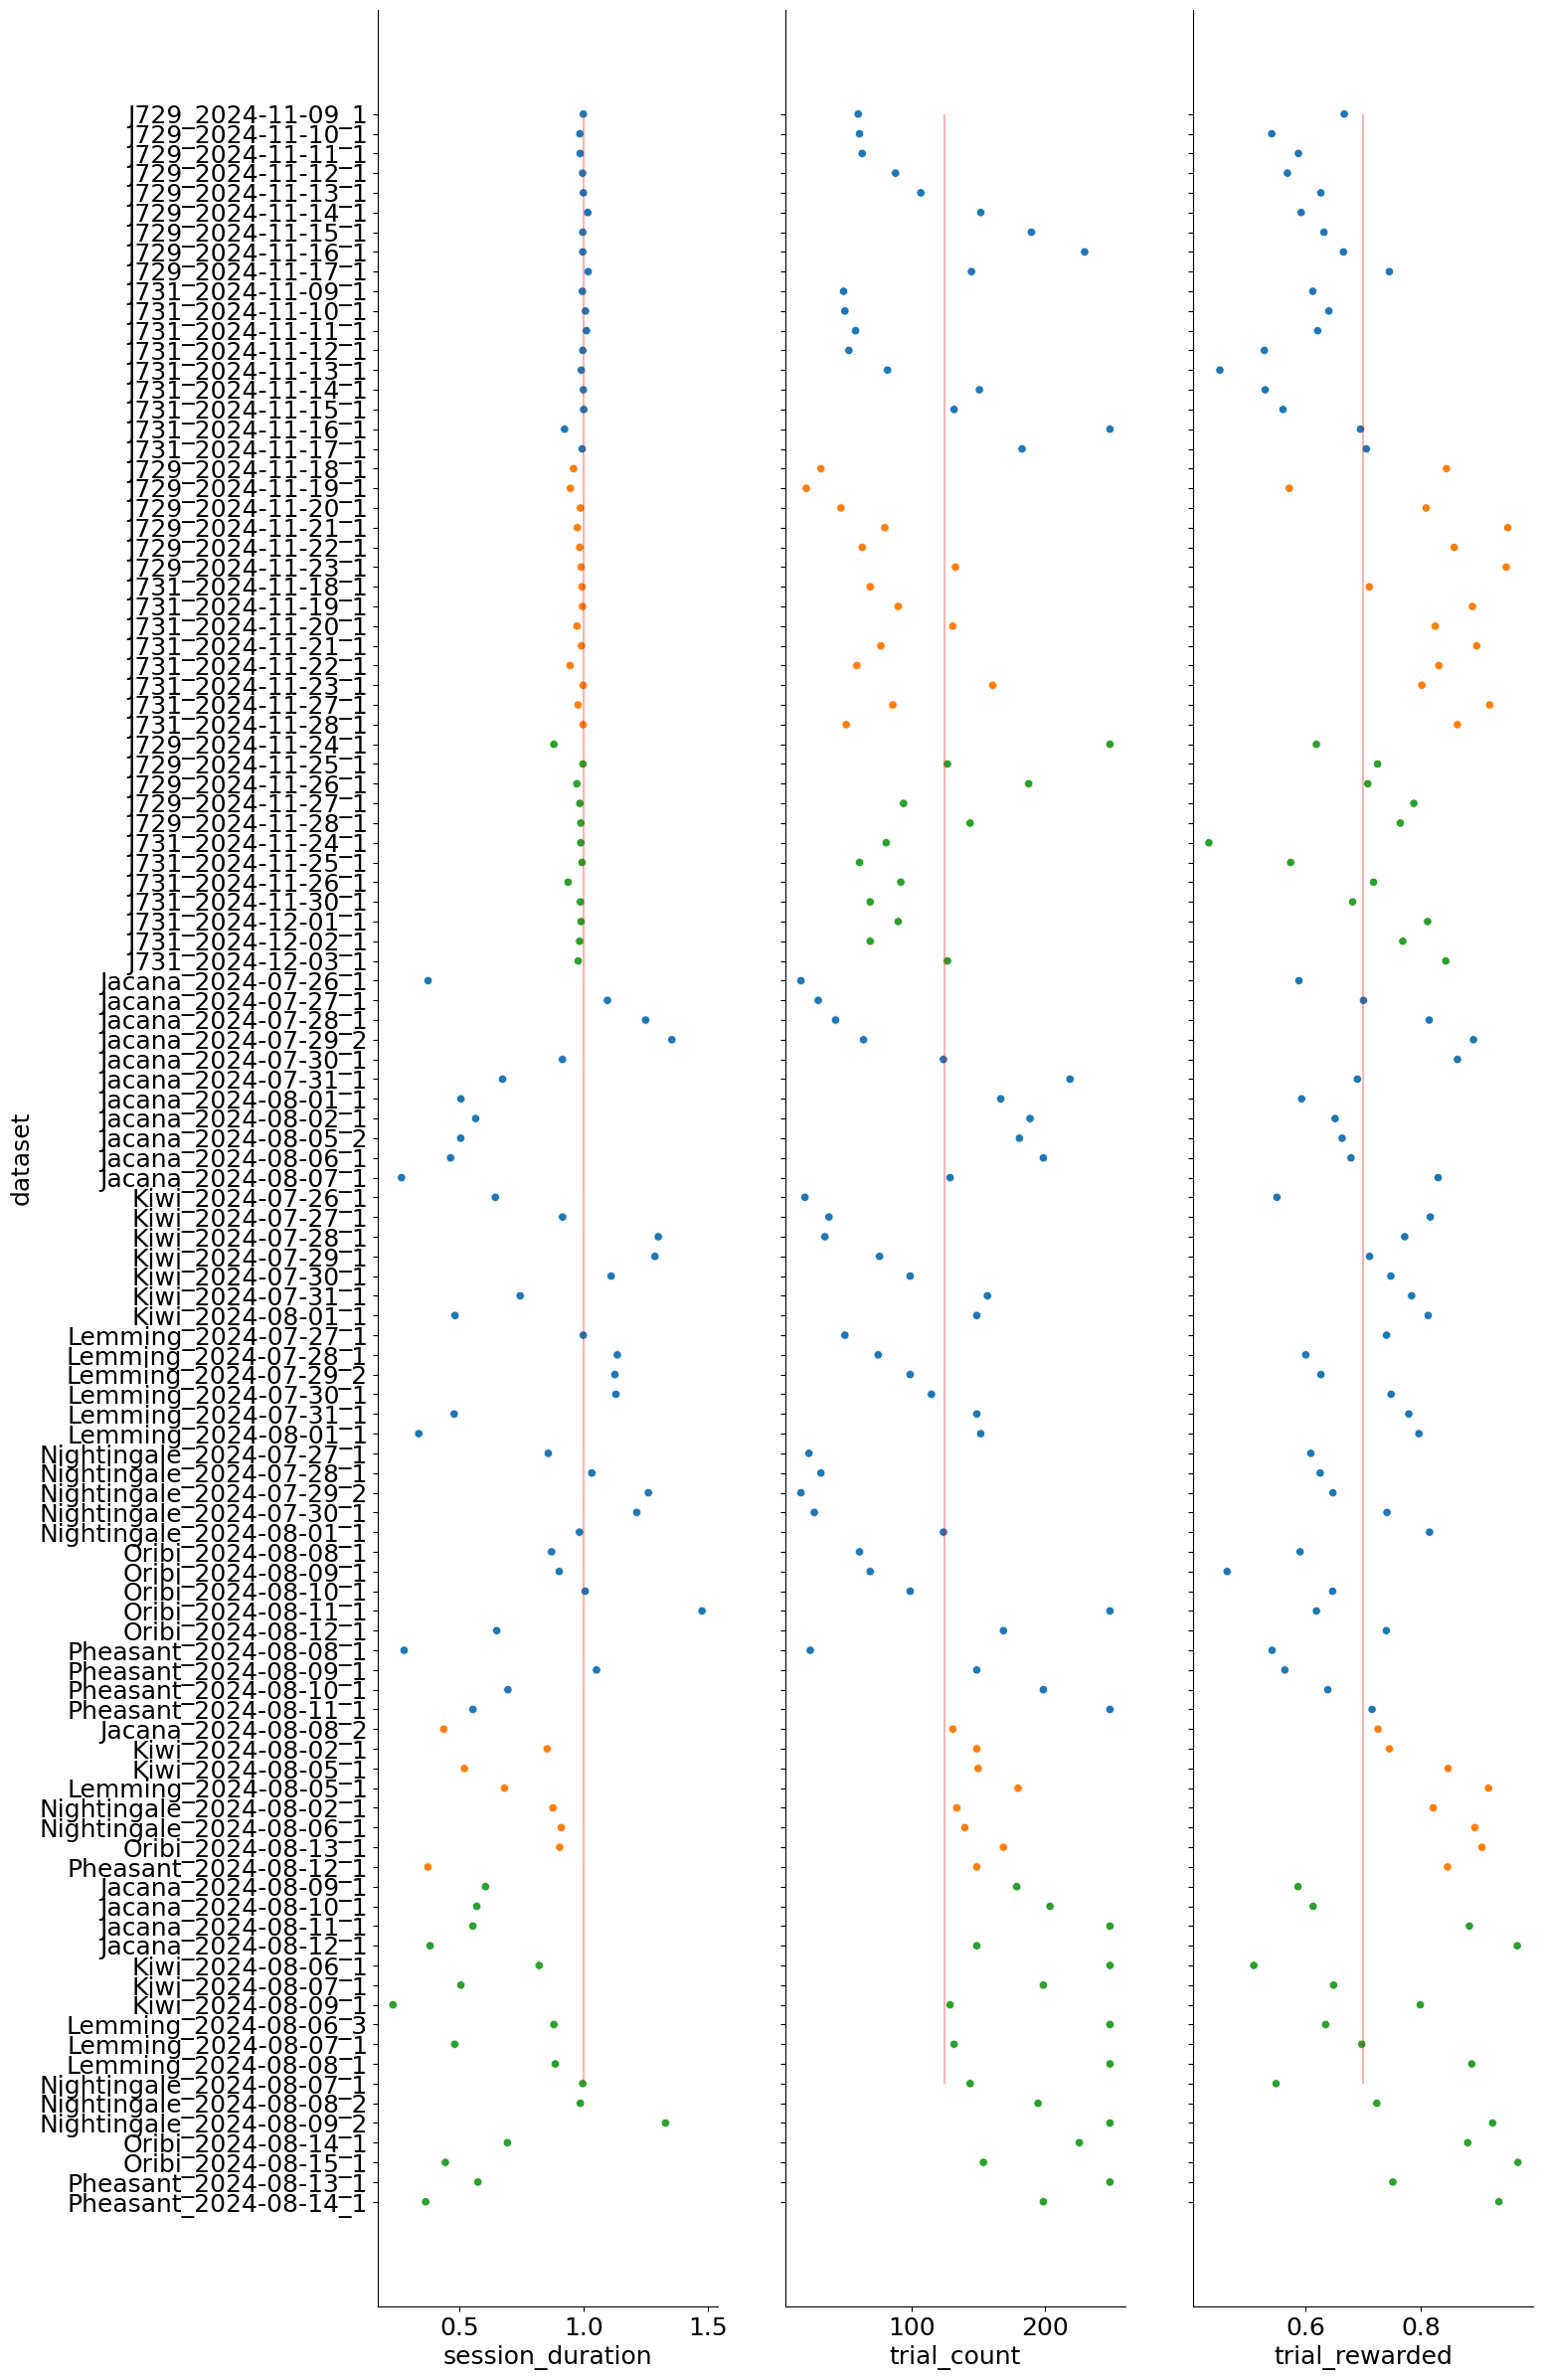

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 30), sharey=True)

sns.scatterplot(
    data=big_df[["session_duration", "dataset", "training_stage"]],
    x="session_duration",
    y="dataset",
    ax=ax[0],
    hue="training_stage",
)

ax[0].vlines(1, 0, 100, color="red", alpha=0.3)

sns.scatterplot(
    data=big_df.groupby(
        ["dataset", "trial"], as_index=False
    ).first(),  # .groupby(["mouse_name", "training_stage", "dataset"], as_index=False).trial_count.first(),
    x="trial_count",
    y="dataset",
    ax=ax[1],
    hue="training_stage",
)

ax[1].vlines(125, 0, 100, color="red", alpha=0.3)

rewarded_trials = (
    big_df.groupby(["dataset", "trial"], as_index=False)
    .first()
    .groupby(["training_stage", "dataset"], as_index=False)
    .trial_rewarded.sum()
)
total = big_df.groupby(
    ["training_stage", "dataset"], as_index=False
).trial_count.first()

rewarded_trials["trial_rewarded"] = (
    rewarded_trials["trial_rewarded"] / total["trial_count"]
)
sns.scatterplot(
    data=rewarded_trials,
    x="trial_rewarded",
    y="dataset",
    ax=ax[2],
    hue="training_stage",
)

ax[2].vlines(0.7, 0, 100, color="red", alpha=0.3)

ax[0].legend([], [], frameon=False)
ax[1].legend([], [], frameon=False)
ax[2].legend([], [], frameon=False)

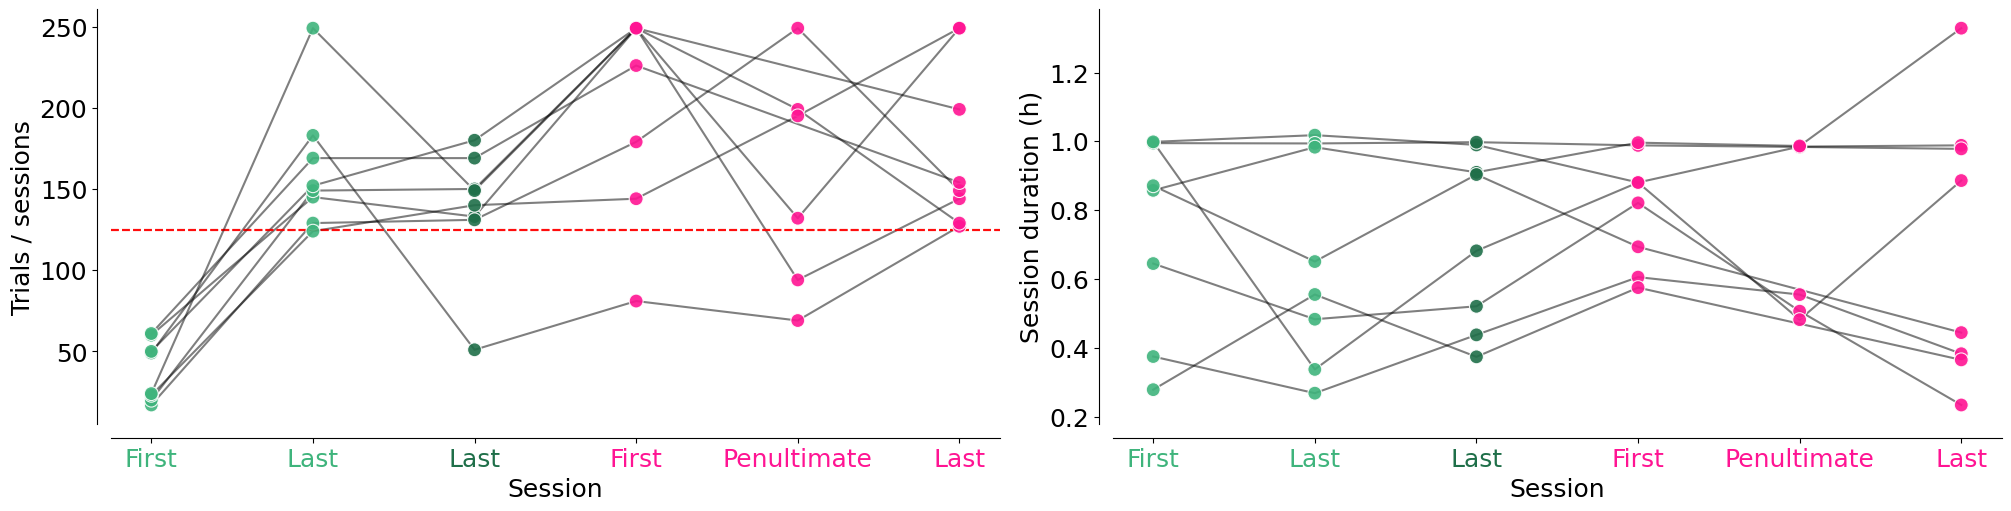

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5), constrained_layout=True)
ax = ax.flatten()

for (i, variable), ylabel in zip(
    enumerate(["trial_count", "session_duration"]),
    ["Trials / sessions", "Session duration (h)"],
):
    for mouse_name in big_df.mouse_name.unique():
        tmp_df = get_training_stage_per_mouse(big_df, mouse_name)
        training_plots(
            tmp_df, mouse_name=mouse_name, variable=variable, ax=ax[i], ylabel=ylabel
        )
    sns.despine(offset=10, ax=ax[i])

for i in range(2):
    # Define tick positions and labels
    stage_positions = np.arange(6)  # Adjust if needed
    stage_labels = ["First", "Last", "Last", "First", "Penultimate", "Last"]
    stage_colors = ["#3FB47C", "#3FB47C", "#1F6F49", "#FF1493", "#FF1493", "#FF1493"]

    ax[i].set_xticks(stage_positions)
    ax[i].set_xticklabels(stage_labels, rotation=0, fontsize=18)

    for j, label in enumerate(ax[i].get_xticklabels()):
        label.set_color(stage_colors[j])

    ax[i].figure.canvas.draw()

plt.savefig(save_fig_path + "trial_count_session_duration.svg", transparent=True)

# Dual occluders

In [11]:
niell_data = pd.read_pickle("big_df_contrast_dual_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_dual.pkl")

big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

In [12]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df[big_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(
    data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y"
)

mean_mouse = (
    j_shaped.groupby(
        ["mouse_name", "dataset", "trial_left_choice", "aperture", "bin_centers"],
        as_index=False,
    )
    .mean(numeric_only=True)
    .copy()
)

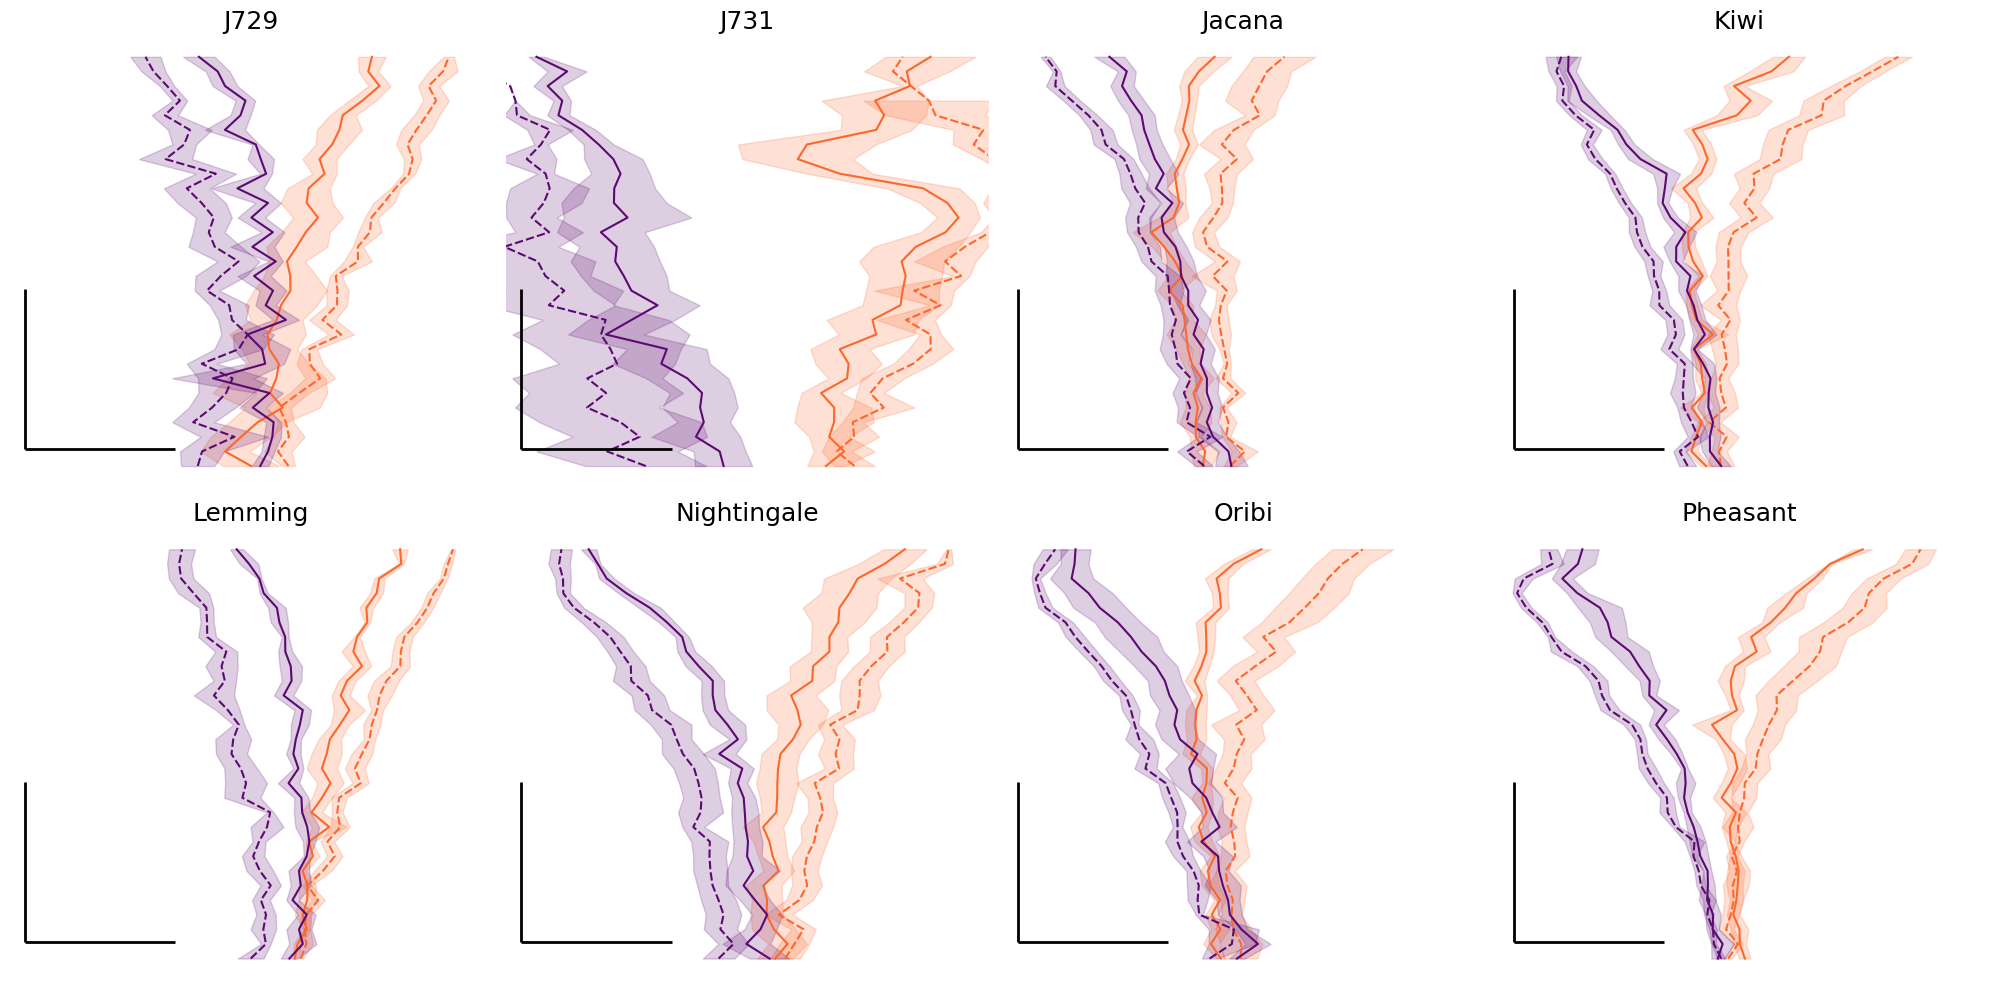

In [14]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()

for j, mouse in enumerate(mean_mouse.mouse_name.unique()):
    plotting.lineplot_flip_axis(
        data=mean_mouse[mean_mouse.mouse_name == mouse],
        x="bin_centers",
        y="x",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
        errorbar="se",
        ax=ax[j],
    )
    ax[j].set_ylabel("y position")
    ax[j].set_xlabel("x position")
    ax[j].set_xlim(-16, 16)
    ax[j].vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
    ax[j].hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
    ax[j].axis("off")
    ax[j].set_title(mouse)
    ax[j].legend([], [], frameon=False)

plt.tight_layout()
plt.savefig(save_fig_path + "mean_trajectory_per_mouse.svg", transparent=True)

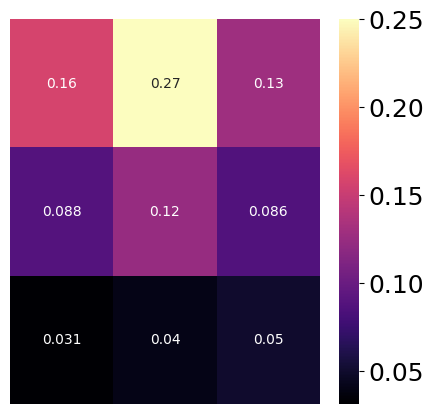

In [17]:
# Averaged initial starting position
fig, ax = plt.subplots(8, 6, figsize=(25, 25))
ax = ax.flatten()

df_init = big_df

hists = []
for i, session in enumerate(df_init.dataset.unique()):
    hist = plotting.plot_init_position_histogram(
        df_init[df_init.dataset == session],
        box_df,
        ax=ax[i],
        bins=3,
        cmap="magma",
        vmax=40,
        is_density=False,
    )

    number_trials = (
        df_init[df_init.dataset == session].groupby(["trial"]).x.first().count()
    )
    hist = hist / number_trials
    hists.append(hist)

    ax[i].set_title(f"{session}")
# plt.close()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.heatmap(
    np.flip(np.mean(hists, axis=0), axis=1).T,
    cmap="magma",
    annot=(np.flip(np.mean(hists, axis=0), axis=1).T),
    vmax=0.25,
)

ax.set_xticks([])
ax.set_yticks([])
plt.show()

Text(0.5, 12.52222222222222, 'Trial duration (s)')

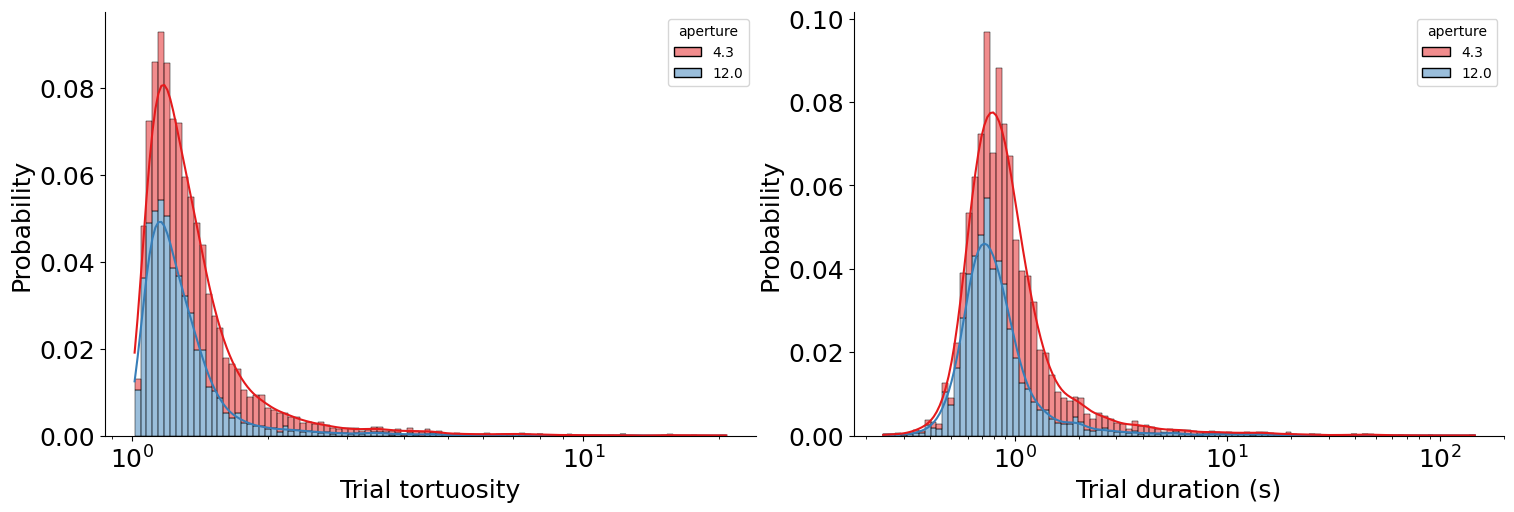

In [21]:
# Tortuosity and duration
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax = plotting.plot_tortuosity_duration_distribution(big_df, ax=ax, log_scale=True)
fig.tight_layout(pad=0.2)
ax[0].set_xlabel("Trial tortuosity")
ax[1].set_xlabel("Trial duration (s)")

In [22]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
interpolated_j_shaped = utils.interpolate_j_shaped(big_df, box_df, n_points=500)

## Multi occluders

In [32]:
niell_data = pd.read_pickle("big_df_contrast_multi_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_multi.pkl")
big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)

box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

In [34]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df[big_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(
    data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y"
)

mean_mouse = (
    j_shaped.groupby(
        ["mouse_name", "dataset", "trial_left_choice", "aperture", "bin_centers"],
        as_index=False,
    )
    .mean(numeric_only=True)
    .copy()
)

IndexError: index 6 is out of bounds for axis 0 with size 6

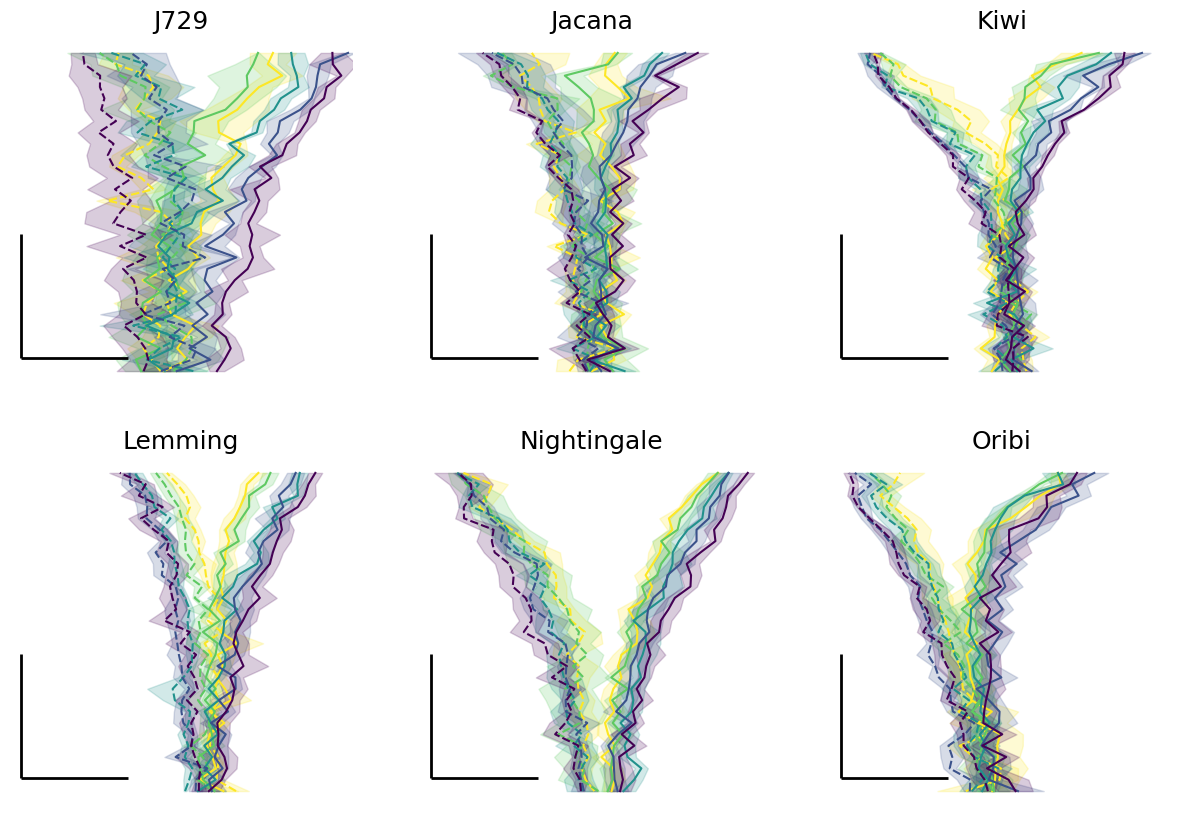

In [35]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax = ax.flatten()

for j, mouse in enumerate(mean_mouse.mouse_name.unique()):
    plotting.lineplot_flip_axis(
        data=mean_mouse[mean_mouse.mouse_name == mouse],
        x="bin_centers",
        y="x",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_multi_aperture,
        style="aperture"
        if len(mean_mouse.aperture.unique()) == 2
        else "trial_left_choice",
        errorbar="se",
        ax=ax[j],
    )
    ax[j].set_ylabel("y position")
    ax[j].set_xlabel("x position")
    ax[j].set_xlim(-16, 16)
    ax[j].vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
    ax[j].hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
    ax[j].axis("off")
    ax[j].set_title(mouse)
    ax[j].legend([], [], frameon=False)

plt.tight_layout()
plt.savefig(save_fig_path + "mean_trajectory_per_mouse.svg", transparent=True)

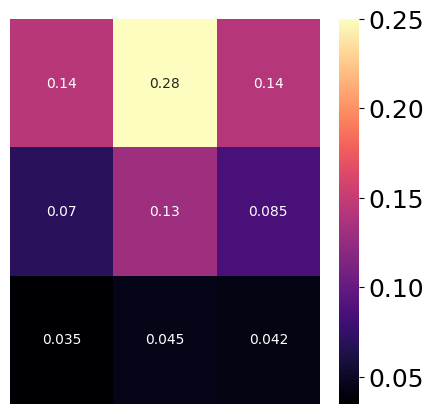

In [36]:
# Averaged initial starting position
fig, ax = plt.subplots(8, 6, figsize=(25, 25))
ax = ax.flatten()

df_init = big_df

hists = []
for i, session in enumerate(df_init.dataset.unique()):
    hist = plotting.plot_init_position_histogram(
        df_init[df_init.dataset == session],
        box_df,
        ax=ax[i],
        bins=3,
        cmap="magma",
        vmax=40,
        is_density=False,
    )

    number_trials = (
        df_init[df_init.dataset == session].groupby(["trial"]).x.first().count()
    )
    hist = hist / number_trials
    hists.append(hist)

    ax[i].set_title(f"{session}")
# plt.close()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.heatmap(
    np.flip(np.mean(hists, axis=0), axis=1).T,
    cmap="magma",
    annot=(np.flip(np.mean(hists, axis=0), axis=1).T),
    vmax=0.25,
)

ax.set_xticks([])
ax.set_yticks([])
plt.show()

Text(0.5, 12.52222222222222, 'Trial duration (s)')

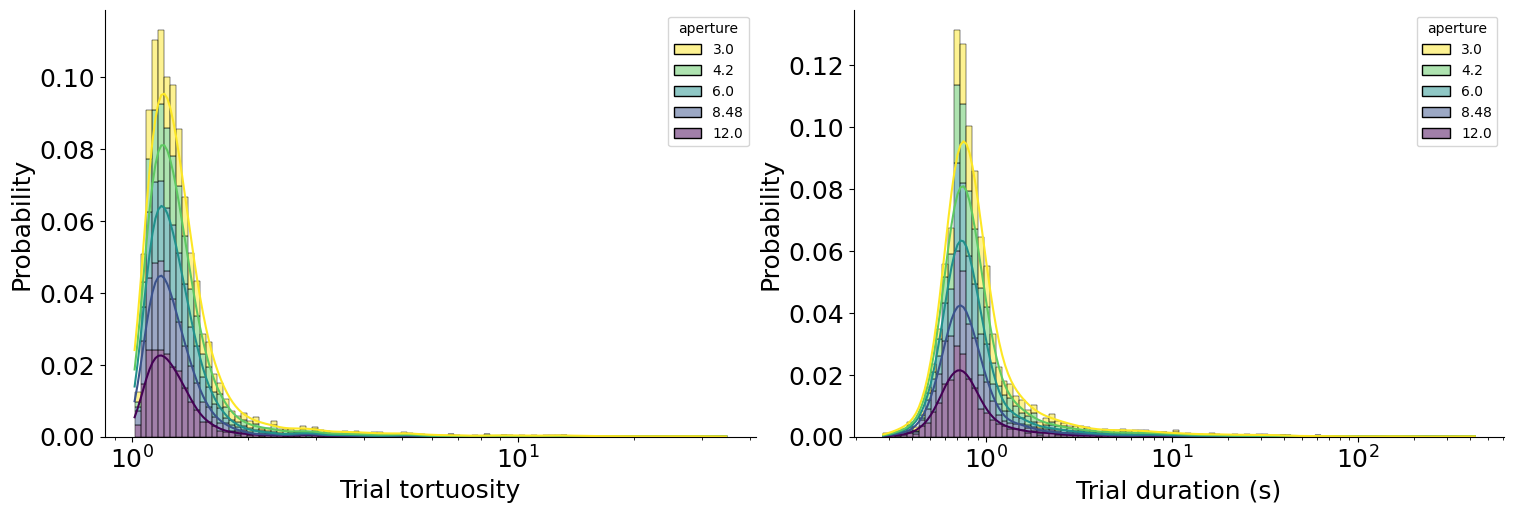

In [37]:
# Tortuosity and duration
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax = plotting.plot_tortuosity_duration_distribution(
    big_df, ax=ax, log_scale=True, cmap=plotting.colors_multi_aperture
)
fig.tight_layout(pad=0.2)
ax[0].set_xlabel("Trial tortuosity")
ax[1].set_xlabel("Trial duration (s)")

In [38]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
interpolated_j_shaped = utils.interpolate_j_shaped(big_df, box_df, n_points=500)

In [40]:
# get data
distance_to_choice_curves = pd.DataFrame(
    mean_mouse.groupby(
        ["trial_length", "aperture"], as_index=False
    ).distance_to_choice.mean()
)

aperture:3.0
Quadratic Term Coefficient: -15.05029708189778
p-value for Quadratic Term: 2.637894227294213e-227
aperture:4.2
Quadratic Term Coefficient: -16.150792599872943
p-value for Quadratic Term: 3.2533818381607504e-263
aperture:6.0
Quadratic Term Coefficient: -14.729333391415024
p-value for Quadratic Term: 2.5776240333987293e-260
aperture:8.48
Quadratic Term Coefficient: -13.792371110637978
p-value for Quadratic Term: 1.7411833141504793e-219
aperture:12.0
Quadratic Term Coefficient: -13.702706424954295
p-value for Quadratic Term: 6.020914117527503e-245


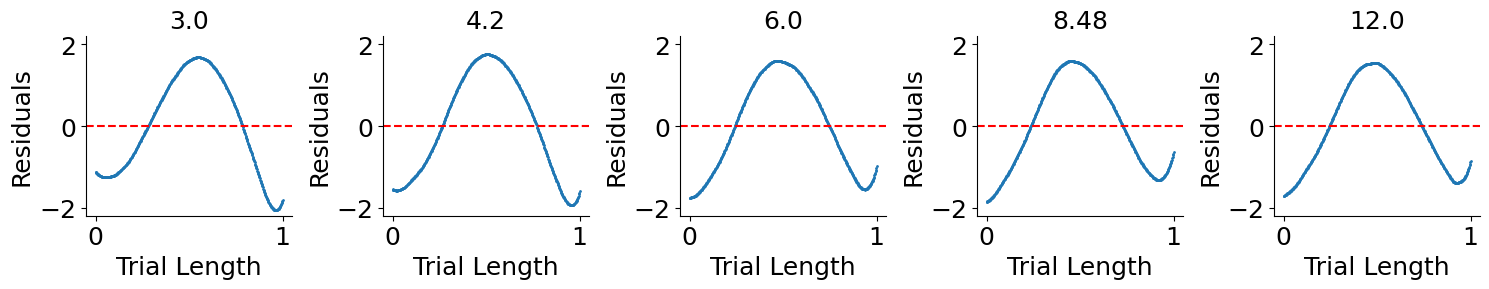

In [41]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

quad_coefs = []
group_labels = []
fig, ax = plt.subplots(
    1, len(distance_to_choice_curves.aperture.unique()), figsize=(15, 3)
)
for j, i in enumerate(distance_to_choice_curves.aperture.unique()):
    print(f"aperture:{i}")
    X = np.linspace(0, 1, 500)
    Y = distance_to_choice_curves[
        distance_to_choice_curves.aperture == i
    ].distance_to_choice.values

    X_reshaped = X.reshape(-1, 1)
    model = LinearRegression().fit(X_reshaped, Y)
    Y_pred = model.predict(X_reshaped)

    residuals = Y - Y_pred

    X_poly = np.column_stack((X, X**2))  # Quadratic model
    X_poly = sm.add_constant(X_poly)  # Add intercept
    model_poly = sm.OLS(Y, X_poly).fit()

    quad_coef = model_poly.params[2]  # Coefficient of X^2
    quad_p_value = model_poly.pvalues[2]

    print(f"Quadratic Term Coefficient: {quad_coef}")
    print(f"p-value for Quadratic Term: {quad_p_value}")

    quad_coefs.append(quad_coef)
    group_labels.append(str(i))

    # Plot Residuals
    ax[j].scatter(X, residuals, s=1, label="Residuals")
    ax[j].axhline(0, color="r", linestyle="--")
    ax[j].set_xlabel("Trial Length")
    ax[j].set_ylabel("Residuals")
    ax[j].set_title(f"{i}")
    ax[j].set_ylim(-2.2, 2.2)

plt.tight_layout()
plt.show()

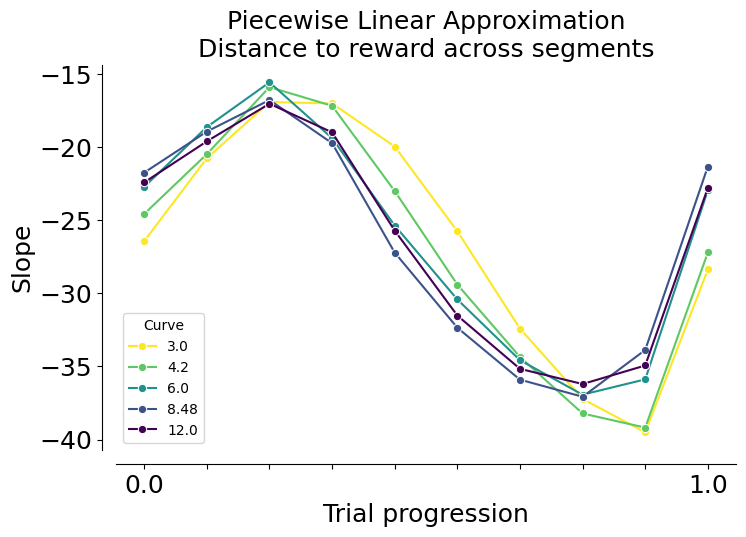

In [42]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

X = np.linspace(0, 1, 500)
num_segments = 10
segment_length = 500 // num_segments

slope_data = []
for j, aperture in enumerate(distance_to_choice_curves.aperture.unique()):
    Y = distance_to_choice_curves[
        distance_to_choice_curves.aperture == aperture
    ].distance_to_choice.values

    slopes = []
    for i in range(num_segments):
        start = i * segment_length
        end = start + segment_length
        X_segment = X[start:end].reshape(-1, 1)
        Y_segment = Y[start:end]

        model = LinearRegression().fit(X_segment, Y_segment)
        slope = model.coef_[0]  # Extract slope (β1)
        slopes.append(slope)

    # Store slopes for comparison
    slope_data.append(
        pd.DataFrame(
            {
                "Slope": slopes,
                "Segment": np.arange(num_segments),
                "Curve": [aperture] * num_segments,
            }
        )
    )

# Combine all data
df_slopes = pd.concat(slope_data)

# Plot the slopes for each segment
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_slopes,
    x="Segment",
    y="Slope",
    hue="Curve",
    marker="o",
    palette=plotting.colors_multi_aperture,
)
plt.xlabel("Trial progression")
plt.ylabel("Slope")
plt.xticks(np.arange(num_segments), [0.0, "", "", "", "", "", "", "", "", 1.0])
plt.title("Piecewise Linear Approximation\nDistance to reward across segments")
sns.despine(offset=10)
plt.show()